# NanoPitch Data Inspection + Visualization

This notebook inspects `clean.npz`, `noise.npz`, and `test.npz` in a memory-safe way and visualizes small samples without loading full multi-GB arrays.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib import format as npformat

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'magma'

In [3]:
def find_data_dir():
    candidates = [
        Path.cwd() / 'data',
        Path.cwd().parent / 'data',
        Path('/home/pc833@drexel.edu/user_data/NanoPitch/data'),
    ]
    for c in candidates:
        if (c / 'clean.npz').exists() and (c / 'noise.npz').exists() and (c / 'test.npz').exists():
            return c.resolve()
    raise FileNotFoundError('Could not find data directory with clean.npz/noise.npz/test.npz')

data_dir = find_data_dir()
print('Using data directory:', data_dir)

Using data directory: /mnt/researchfiles/ECE IMAPLE/cluster_data/user_data/pc833/NanoPitch/data


In [4]:
def read_npy_header_from_npz(npz_path, array_name):
    member = f'{array_name}.npy'
    with zipfile.ZipFile(npz_path, 'r') as zf:
        with zf.open(member, 'r') as f:
            major, minor = npformat.read_magic(f)
            if (major, minor) == (1, 0):
                shape, fortran_order, dtype = npformat.read_array_header_1_0(f)
            elif (major, minor) in [(2, 0), (3, 0)]:
                shape, fortran_order, dtype = npformat.read_array_header_2_0(f)
            else:
                raise ValueError(f'Unsupported .npy version {(major, minor)} in {member}')
            header_end = f.tell()
    return {
        'shape': shape,
        'fortran_order': fortran_order,
        'dtype': np.dtype(dtype),
        'header_end': header_end,
    }

def read_prefix_from_npz(npz_path, array_name, max_items=200000):
    info = read_npy_header_from_npz(npz_path, array_name)
    shape = info['shape']
    dtype = info['dtype']
    if info['fortran_order']:
        raise ValueError(f'{array_name}: fortran_order=True not supported in this sampler')

    total = int(np.prod(shape))
    take = min(total, max_items)
    nbytes = take * dtype.itemsize

    member = f'{array_name}.npy'
    with zipfile.ZipFile(npz_path, 'r') as zf:
        with zf.open(member, 'r') as f:
            f.read(info['header_end'])
            buf = f.read(nbytes)

    prefix = np.frombuffer(buf, dtype=dtype, count=take)
    return info, prefix


In [5]:
datasets = ['clean.npz', 'noise.npz', 'test.npz']
meta = {}

for ds in datasets:
    npz_path = data_dir / ds
    print(f'\n=== {ds} ===')
    with zipfile.ZipFile(npz_path, 'r') as zf:
        names = [Path(i.filename).stem for i in zf.infolist() if i.filename.endswith('.npy')]
    meta[ds] = {}
    for name in names:
        info = read_npy_header_from_npz(npz_path, name)
        meta[ds][name] = info
        print(f"{name:12s} shape={info['shape']} dtype={info['dtype']} fortran={info['fortran_order']}")


=== clean.npz ===
mel          shape=(36372498, 40) dtype=float16 fortran=False
f0           shape=(36372498,) dtype=float16 fortran=False
vad          shape=(36372498,) dtype=float16 fortran=False
lengths      shape=(40940,) dtype=int32 fortran=False

=== noise.npz ===
mel          shape=(15283949, 40) dtype=float16 fortran=False
lengths      shape=(17616,) dtype=int32 fortran=False

=== test.npz ===
clips        shape=(600, 500, 40) dtype=float16 fortran=False
clean        shape=(600, 500, 40) dtype=float16 fortran=False
f0           shape=(600, 500) dtype=float16 fortran=False
vad          shape=(600, 500) dtype=float16 fortran=False
snr          shape=(600,) dtype=float32 fortran=False
snr_levels   shape=(6,) dtype=float32 fortran=False
clip_len     shape=() dtype=int32 fortran=False


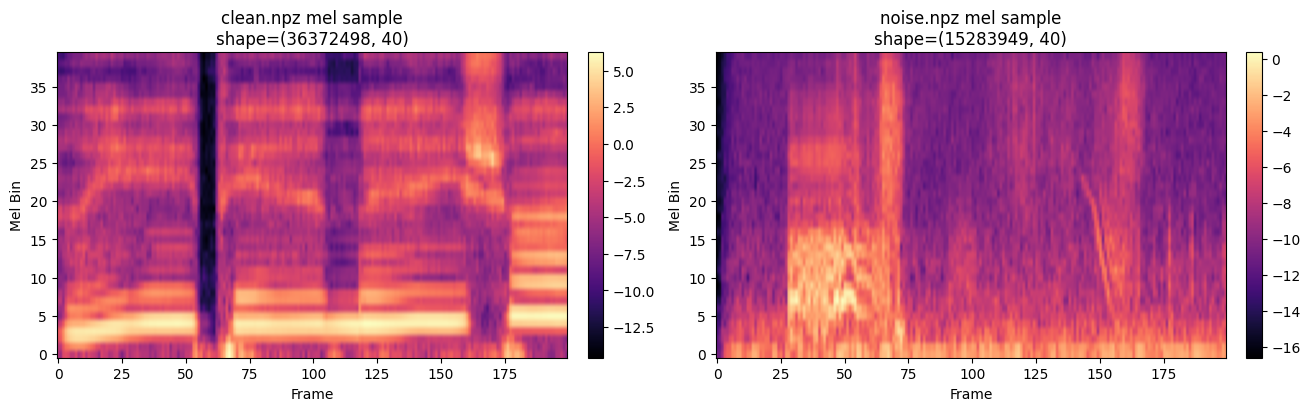

In [6]:
# Visualize small mel slices safely from clean/noise archives
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

for ax, ds in zip(axes, ['clean.npz', 'noise.npz']):
    npz_path = data_dir / ds
    info, prefix = read_prefix_from_npz(npz_path, 'mel', max_items=200 * 40)
    # Expected mel layout is [..., 40]. We display first 200 frames x 40 bins.
    mel2d = prefix.reshape(-1, 40)[:200]
    im = ax.imshow(mel2d.T, aspect='auto', origin='lower')
    ax.set_title(f'{ds} mel sample\nshape={info["shape"]}')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Mel Bin')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [7]:
# Full test set is small enough to load directly for richer plots
test = np.load(data_dir / 'test.npz', allow_pickle=False)
print('Loaded test.npz keys:', test.files)
for k in test.files:
    print(f'  {k:12s} shape={test[k].shape} dtype={test[k].dtype}')

Loaded test.npz keys: ['clips', 'clean', 'f0', 'vad', 'snr', 'snr_levels', 'clip_len']
  clips        shape=(600, 500, 40) dtype=float16
  clean        shape=(600, 500, 40) dtype=float16
  f0           shape=(600, 500) dtype=float16
  vad          shape=(600, 500) dtype=float16
  snr          shape=(600,) dtype=float32
  snr_levels   shape=(6,) dtype=float32
  clip_len     shape=() dtype=int32


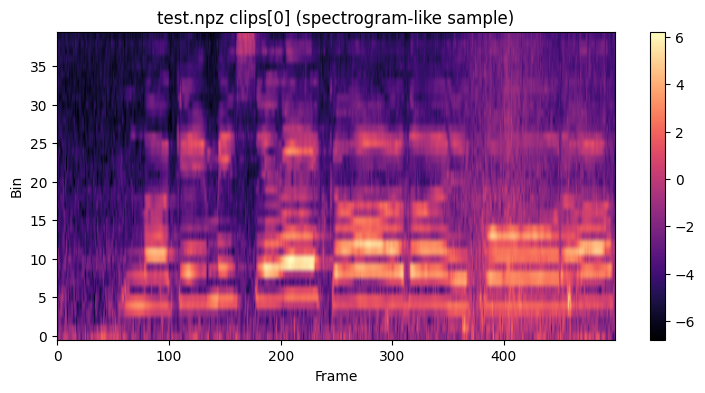

In [8]:
# Test clip spectrogram sample
clips = test['clips']
sample = clips[0] if clips.ndim >= 3 else clips

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(sample.T, aspect='auto', origin='lower')
ax.set_title('test.npz clips[0] (spectrogram-like sample)')
ax.set_xlabel('Frame')
ax.set_ylabel('Bin')
plt.colorbar(im, ax=ax)
plt.show()

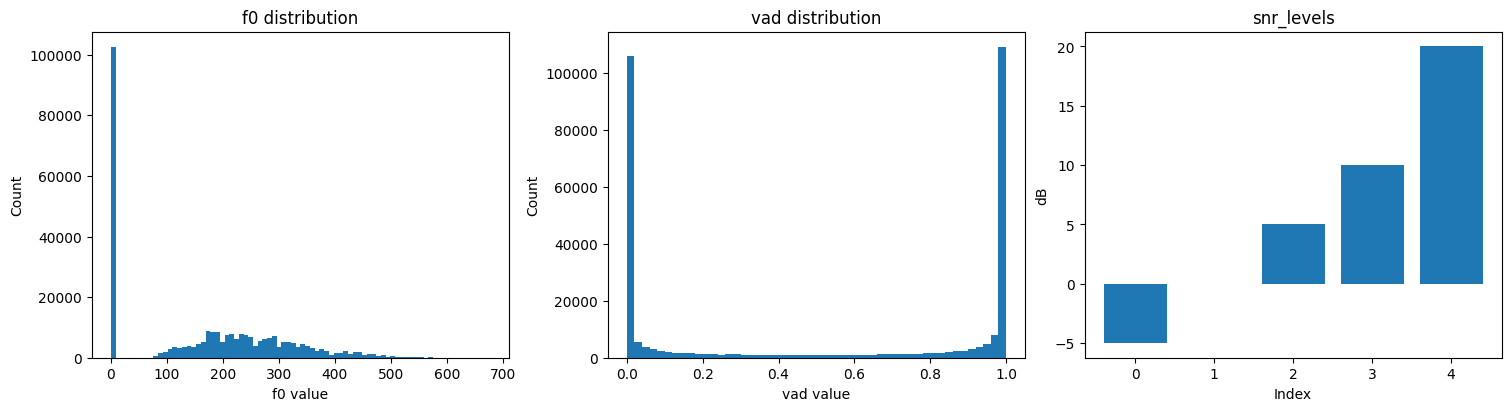

In [9]:
# Simple distributions from test set labels/targets
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(test['f0'].ravel(), bins=80)
axes[0].set_title('f0 distribution')
axes[0].set_xlabel('f0 value')
axes[0].set_ylabel('Count')

axes[1].hist(test['vad'].ravel(), bins=50)
axes[1].set_title('vad distribution')
axes[1].set_xlabel('vad value')
axes[1].set_ylabel('Count')

axes[2].bar(range(len(test['snr_levels'])), test['snr_levels'])
axes[2].set_title('snr_levels')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('dB')

plt.show()